# TidalSense Study — Operational Report

**Audience:** clinical and product leadership.  
**Period covered:** 30-day deployment across 10 GP practices.  
**Purpose:** summarise how the study is going and surface the issues that need management attention.

In [1]:
# ── Helper functions (kept inline so the notebook is self-contained) ──
import json
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Use the PNG renderer (via kaleido) so each chart is baked into the notebook
# output as an actual image. This means the figures render everywhere — locally
# in Jupyter, on GitHub, in nbviewer, in VS Code — without needing plotly.js to
# load. We also widen the default size for legibility.
pio.renderers.default = "png"
pio.kaleido.scope.default_width = 1100
pio.kaleido.scope.default_height = 480

# Resolve data folder whether the notebook is launched from repo root or notebooks/
_here = Path.cwd()
DATA_DIR = next(p for p in [_here / "data/raw", _here.parent / "data/raw"] if p.exists())

def load_software():
    df = pd.read_csv(DATA_DIR / "software_table.csv",
                     parse_dates=["test_log_time", "test_processed_time"])
    df["handset_num"] = df["handset_ID"].str.extract(r"(\d+)$").astype(int)
    df["processing_delay_s"] = (df["test_processed_time"] - df["test_log_time"]).dt.total_seconds()
    df["date"] = df["test_log_time"].dt.date
    df["dow"] = df["test_log_time"].dt.day_name()
    df["hour"] = df["test_log_time"].dt.hour
    df["is_weekend"] = df["test_log_time"].dt.weekday >= 5
    df["any_automated_error"] = (df["automated_check_hardware_error"]
                                 | df["automated_check_software_error"]
                                 | df["miscalibration"])
    return df

def load_hardware():
    return pd.read_csv(DATA_DIR / "hardware_telemetry_table.csv", parse_dates=["log_time"])

def _safe_loads(s):
    try:
        return json.loads(s) if isinstance(s, str) else {}
    except Exception:
        return {}

def parse_telemetry(hw):
    out = hw.copy()
    parsed = out["message"].apply(_safe_loads)
    out["status"] = parsed.apply(lambda d: d.get("status"))
    out["voltage"] = parsed.apply(lambda d: d.get("voltage"))
    out["signal_strength"] = parsed.apply(lambda d: d.get("signal_strength"))
    out["firmware_version"] = parsed.apply(lambda d: d.get("firmware_version"))
    return out

def attach_firmware(sw, hw_parsed):
    """For each test, attach the firmware version active on that handset at that time."""
    fw = (hw_parsed.loc[hw_parsed["component"] == "firmware",
                        ["ID", "log_time", "firmware_version"]]
          .dropna()
          .rename(columns={"ID": "handset_num", "log_time": "fw_time"})
          .sort_values(["handset_num", "fw_time"]))
    pieces = []
    for h, g in sw.sort_values(["handset_num", "test_log_time"]).groupby("handset_num", sort=False):
        fw_g = fw[fw["handset_num"] == h]
        if fw_g.empty:
            g = g.assign(firmware_at_test=pd.NA)
        else:
            g = pd.merge_asof(
                g, fw_g[["fw_time", "firmware_version"]]
                    .rename(columns={"fw_time": "test_log_time",
                                     "firmware_version": "firmware_at_test"}),
                on="test_log_time", direction="backward")
        pieces.append(g)
    return pd.concat(pieces, ignore_index=True).sort_values("test_log_time")

def handset_health(sw, hw_parsed):
    """Combined per-handset summary used by the analysis notebook."""
    sw_g = sw.groupby("handset_num").agg(
        practice=("practice_ID","first"),
        tests=("test_log_time","count"),
        miscal=("miscalibration","sum"),
        hw_err=("automated_check_hardware_error","sum"),
        sw_err=("automated_check_software_error","sum"),
        timeouts=("user_error", lambda s: (s=="Timeout").sum()),
        last_test=("test_log_time","max"),
    )
    for col, base in [("miscal_rate","miscal"),("hw_err_rate","hw_err"),
                      ("sw_err_rate","sw_err"),("timeout_rate","timeouts")]:
        sw_g[col] = sw_g[base] / sw_g["tests"]
    batt = (hw_parsed.query("component == 'battery'")
            .groupby("ID")["voltage"].agg(batt_mean="mean", batt_min="min"))
    sig = (hw_parsed.query("component == 'modem'")
           .groupby("ID")["signal_strength"].agg(signal_mean="mean", signal_min="min"))
    crit_b = (hw_parsed.query("component == 'battery' and status == 'CRITICAL'")
              .groupby("ID").size().rename("battery_critical_events"))
    crit_m = (hw_parsed.query("component == 'modem' and status == 'CRITICAL'")
              .groupby("ID").size().rename("modem_critical_events"))
    fw_evt = (hw_parsed.query("component == 'firmware'")
              .groupby("ID").agg(firmware_events=("firmware_version","count"),
                                 last_firmware=("firmware_version","last"),
                                 last_telemetry=("log_time","max")))
    tel = hw_parsed.groupby("ID").size().rename("telemetry_events")
    out = (sw_g.join(batt).join(sig).join(crit_b).join(crit_m).join(fw_evt).join(tel))
    out["battery_critical_events"] = out["battery_critical_events"].fillna(0).astype(int)
    out["modem_critical_events"]   = out["modem_critical_events"].fillna(0).astype(int)
    out["silence_days"] = (out["last_test"] - out["last_telemetry"]).dt.days
    return out


In [2]:
sw = load_software()
hw_parsed = parse_telemetry(load_hardware())
sw = attach_firmware(sw, hw_parsed)
hh = handset_health(sw, hw_parsed)
print(f'Loaded {len(sw):,} tests across {sw.practice_ID.nunique()} practices, {sw.handset_ID.nunique()} handsets.')

Loaded 8,678 tests across 10 practices, 20 handsets.


---
# Executive summary

- The study is **delivering at planned volume** (~290 tests/day) with broad practice coverage.
- **One handset is failing** and is dragging the fleet error rate up by ~7 points on its own. Replace immediately.
- **A firmware release (v1.1.2) regressed quality** for ~5 days before being patched. Add a release-gate metric.
- **Two GP sites have weak cellular connectivity**, slowing test processing and risking data loss. Site survey needed.
- **Four administrators have outsized timeout rates** (4–9× their peers). Targeted retraining will lift completion rates.
- **Three handsets stopped reporting telemetry** mid-study while continuing to run tests — they have a broken uplink and have not received the latest firmware.
- **Diagnostic positivity rate varies 5× across practices** — needs clinical review (likely referral-mix, not device drift).
- **PRC-009 ran 33% more tests than the median practice** — confirm with the site whether this is real demand or a workflow artefact.


## Headline numbers

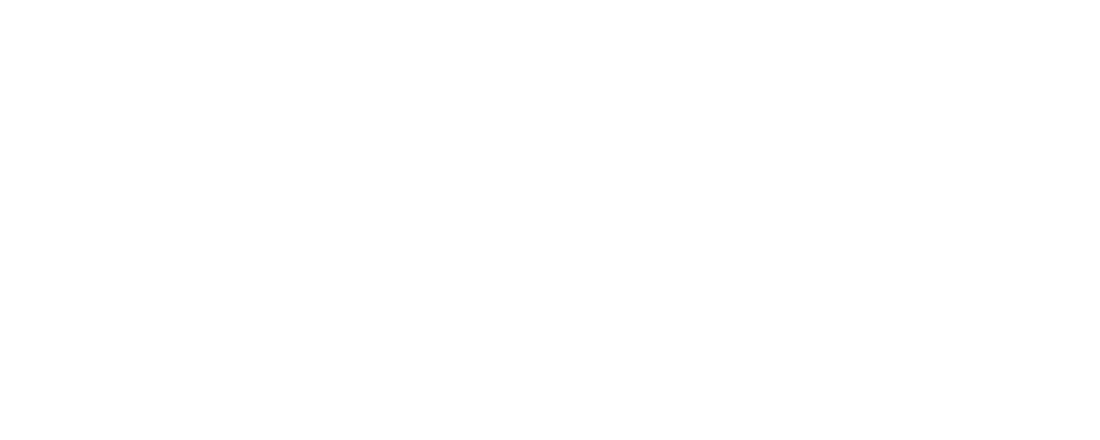

In [3]:
n_tests = len(sw)
n_practices = sw.practice_ID.nunique()
n_handsets = sw.handset_ID.nunique()
n_admins = sw.administrator_ID.nunique()
tests_per_day = sw.groupby('date').size().mean()
auto_err = sw['any_automated_error'].mean()
user_err = (sw['user_error'] != 'no_error').mean()
pos_rate = (sw['diagnosis'] == 'positive').mean()
weekend = sw['is_weekend'].mean()

kpis = [
    ('Tests completed',   f'{n_tests:,}',           'green'),
    ('Tests per day',     f'{tests_per_day:.0f}',    'green'),
    ('Practices live',    f'{n_practices}',          'green'),
    ('Active handsets',   f'{n_handsets}',           'green'),
    ('Administrators',    f'{n_admins}',             'green'),
    ('Positive diagnosis',f'{pos_rate:.1%}',         'gray'),
    ('Auto-check errors', f'{auto_err:.1%}',         'red' if auto_err > 0.07 else 'green'),
    ('User-side errors',  f'{user_err:.1%}',         'orange' if user_err > 0.05 else 'green'),
    ('Weekend tests',     f'{weekend:.1%}',          'orange' if weekend > 0.02 else 'green'),
]
fig = make_subplots(rows=3, cols=3, specs=[[{'type':'indicator'}]*3]*3)
for i, (label, value, colour) in enumerate(kpis):
    fig.add_trace(go.Indicator(mode='number', value=0,
        title={'text': f'<b>{label}</b><br><span style=\"font-size:1.1em;color:{colour}\">{value}</span>'},
        number={'font':{'size':1, 'color':'white'}}),
        row=i//3+1, col=i%3+1)
fig.update_layout(height=440, margin=dict(t=40,l=20,r=20,b=20))
fig.show()

## Activity over time

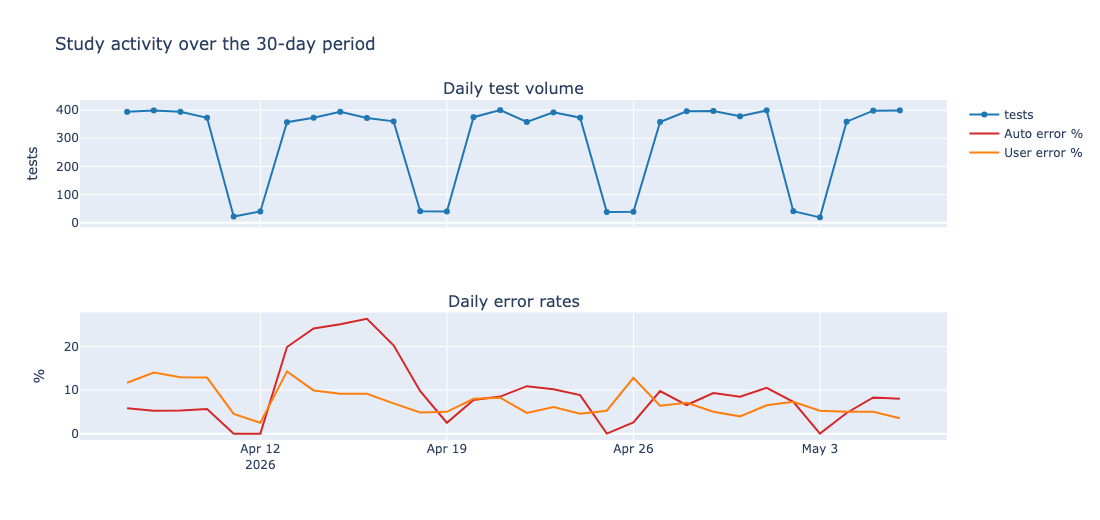

In [4]:
daily = sw.groupby('date').agg(
    tests=('test_log_time','count'),
    auto_err=('any_automated_error','mean'),
    user_err=('user_error', lambda s: (s != 'no_error').mean()),
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=('Daily test volume', 'Daily error rates'))
fig.add_trace(go.Scatter(x=daily['date'], y=daily['tests'], mode='lines+markers',
                         name='tests', line=dict(color='#1f77b4')), row=1, col=1)
fig.add_trace(go.Scatter(x=daily['date'], y=daily['auto_err']*100,
                         mode='lines', name='Auto error %', line=dict(color='#d62728')),
              row=2, col=1)
fig.add_trace(go.Scatter(x=daily['date'], y=daily['user_err']*100,
                         mode='lines', name='User error %', line=dict(color='#ff7f0e')),
              row=2, col=1)
fig.update_layout(height=520, title_text='Study activity over the 30-day period')
fig.update_yaxes(title_text='tests', row=1, col=1)
fig.update_yaxes(title_text='%', row=2, col=1)
fig.show()

**Reading this chart.** Volume is steady mid-week and dips on weekends. The error-rate spike in mid-April is the firmware-1.1.2 regression (detailed below). The persistent ~3% baseline error is dominated by a single broken handset.

## Performance by practice

In [5]:
prac = sw.groupby('practice_ID').agg(
    tests=('test_log_time','count'),
    auto_err_rate=('any_automated_error','mean'),
    timeout_rate=('user_error', lambda s: (s=='Timeout').mean()),
    positive_rate=('diagnosis', lambda s: (s=='positive').mean()),
).round(3).sort_values('tests', ascending=False)
prac

,tests,auto_err_rate,timeout_rate,positive_rate
practice_ID,,,,
PRC-009,1116,0.086,0.024,0.149
PRC-001,857,0.075,0.025,0.100
PRC-008,854,0.093,0.034,0.522
PRC-003,850,0.095,0.062,0.099
PRC-005,850,0.080,0.067,0.140
PRC-006,849,0.093,0.021,0.140
PRC-010,838,0.073,0.038,0.146
PRC-002,835,0.061,0.104,0.267
PRC-004,825,0.072,0.024,0.451


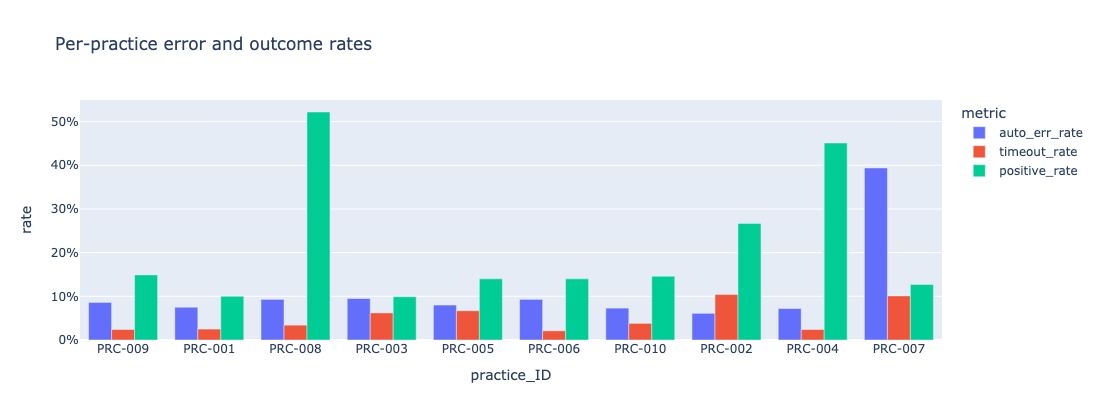

In [6]:
fig = px.bar(prac.reset_index(),
             x='practice_ID',
             y=['auto_err_rate','timeout_rate','positive_rate'],
             barmode='group',
             title='Per-practice error and outcome rates',
             labels={'value':'rate','variable':'metric'})
fig.update_layout(height=420, yaxis_tickformat='.0%')
fig.show()

---
# Issues requiring action

Each finding below: **what we observed → likely cause → recommended action**, with supporting evidence. Findings are ordered by impact / urgency.

## Finding 1 — Replace handset-00013 immediately

**What we found.** This single handset has miscalibrated on **79% of its tests**, produced all 43 CRITICAL battery alerts in the fleet, and operates at a mean battery voltage of 3.38 V vs the fleet norm of 3.82 V.

**Likely cause.** Battery degradation and probable sensor-block damage. Symptoms are device-specific, not site-specific.

**Action.** Pull the unit from service today, ship a replacement to PRC-007, RMA the device for engineering teardown.

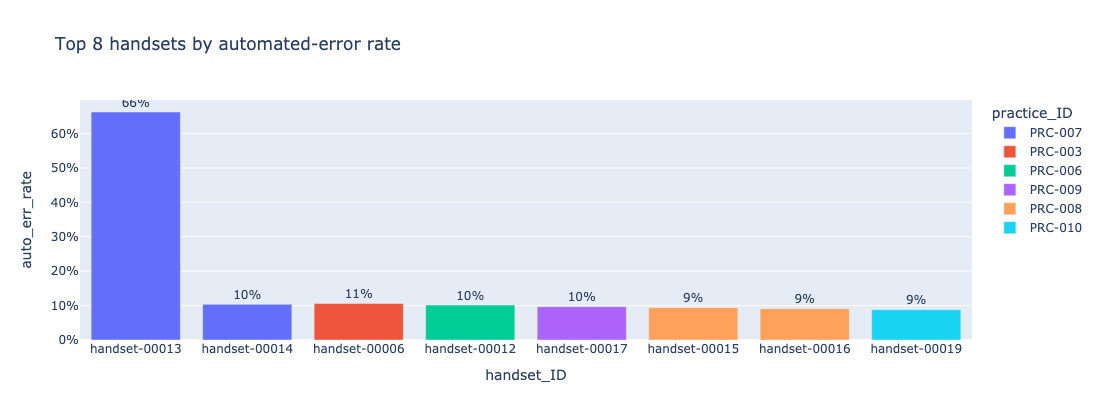

In [7]:
worst = (sw.groupby(['handset_ID','practice_ID'])
         .agg(tests=('test_log_time','count'),
              miscal_rate=('miscalibration','mean'),
              auto_err_rate=('any_automated_error','mean'))
         .reset_index().sort_values('auto_err_rate', ascending=False).head(8))
fig = px.bar(worst, x='handset_ID', y='auto_err_rate', color='practice_ID',
             title='Top 8 handsets by automated-error rate',
             text=worst['auto_err_rate'].apply(lambda v: f'{v:.0%}'))
fig.update_layout(height=420, yaxis_tickformat='.0%')
fig.update_traces(textposition='outside')
fig.show()

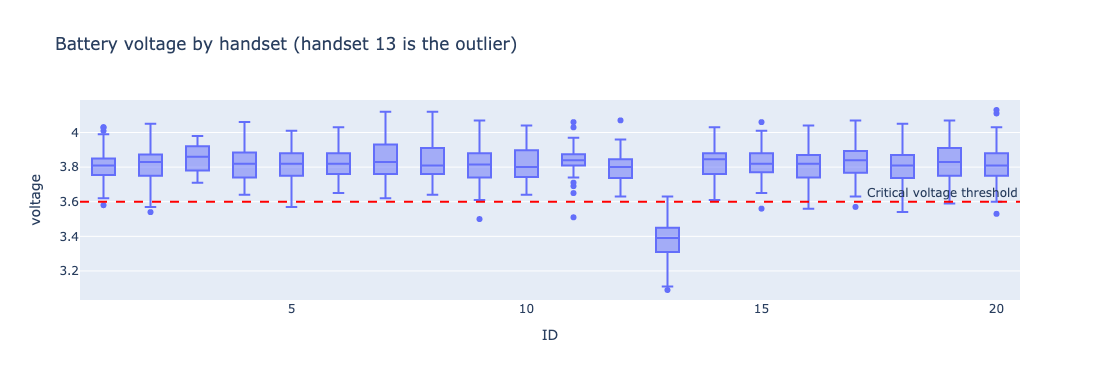

In [8]:
# Battery voltage trace for handset-00013 vs fleet median
batt = hw_parsed.query("component == 'battery'")
fig = px.box(batt, x='ID', y='voltage',
             title='Battery voltage by handset (handset 13 is the outlier)')
fig.add_hline(y=3.6, line_dash='dash', line_color='red',
              annotation_text='Critical voltage threshold')
fig.update_layout(height=380)
fig.show()

## Finding 2 — Post-mortem firmware v1.1.2

**What we found.** During the days v1.1.2 was active on the fleet, the automated software-check error rate was **~20%** — roughly 10× the rate on neighbouring versions. The next release (v1.2.0) returned the rate to baseline without intervention.

**Likely cause.** A defect introduced in the v1.1.2 build, fixed in v1.2.0.

**Action.** Run a release post-mortem on what changed in v1.1.2. Add software-check error-rate as a release-gate metric so any future regression is caught before fleet-wide rollout.

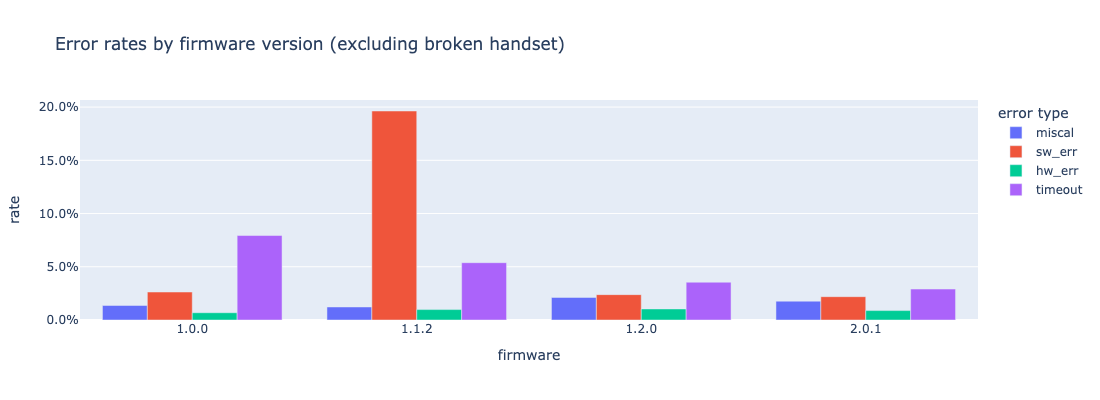

,firmware_at_test,tests,miscal,sw_err,hw_err,timeout
0,1.0.0,1903,0.0137,0.0263,0.0068,0.0793
1,1.1.2,1635,0.0122,0.1963,0.0098,0.0538
2,1.2.0,2309,0.0212,0.0238,0.0104,0.0355
3,2.0.1,2374,0.0177,0.0219,0.0088,0.0291


In [9]:
# Exclude handset-00013 so its broken behaviour does not contaminate the comparison
fwq = sw[sw.handset_num != 13].groupby('firmware_at_test').agg(
    tests=('test_log_time','count'),
    miscal=('miscalibration','mean'),
    sw_err=('automated_check_software_error','mean'),
    hw_err=('automated_check_hardware_error','mean'),
    timeout=('user_error', lambda s: (s=='Timeout').mean()),
).reset_index()
fig = px.bar(fwq, x='firmware_at_test',
             y=['miscal','sw_err','hw_err','timeout'],
             barmode='group',
             title='Error rates by firmware version (excluding broken handset)',
             labels={'value':'rate','variable':'error type','firmware_at_test':'firmware'})
fig.update_layout(height=400, yaxis_tickformat='.1%')
fig.show()
fwq.round(4)

## Finding 3 — Site connectivity at PRC-003 and PRC-007

**What we found.** Mean modem signal at these two sites is roughly **6–9** vs a fleet average of **25**. Both sites also account for the bulk of CRITICAL modem alerts, and have ~2× the test-processing delay of other practices.

**Likely cause.** Building shielding or weak carrier coverage at the site — this is a *physical environment* issue, not a device issue.

**Action.** Site survey at both practices. Consider Wi-Fi backhaul, a signal repeater, or a different mobile carrier.

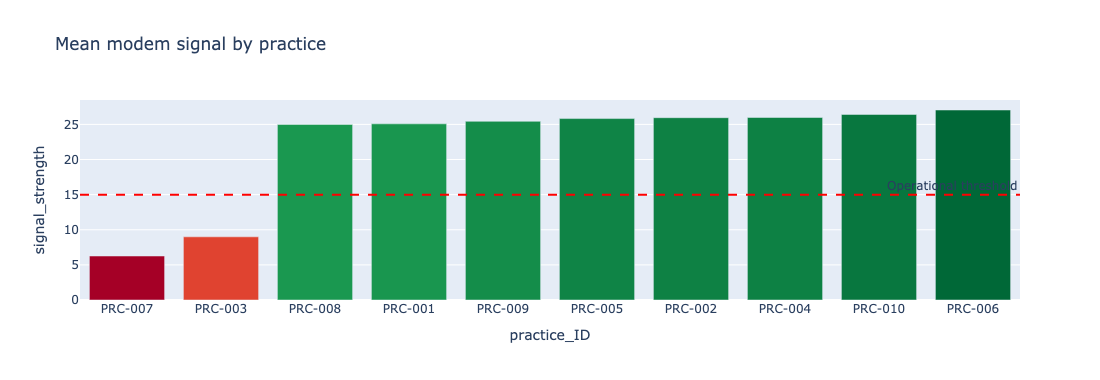

In [10]:
by_practice_signal = (
    hw_parsed.query("component == 'modem'")
    .merge(sw[['handset_num','practice_ID']].drop_duplicates(),
           left_on='ID', right_on='handset_num')
    .groupby('practice_ID')['signal_strength'].mean()
    .reset_index().sort_values('signal_strength')
)
fig = px.bar(by_practice_signal, x='practice_ID', y='signal_strength',
             title='Mean modem signal by practice',
             color='signal_strength', color_continuous_scale='RdYlGn')
fig.add_hline(y=15, line_dash='dash', line_color='red',
              annotation_text='Operational threshold')
fig.update_layout(height=380, coloraxis_showscale=False)
fig.show()

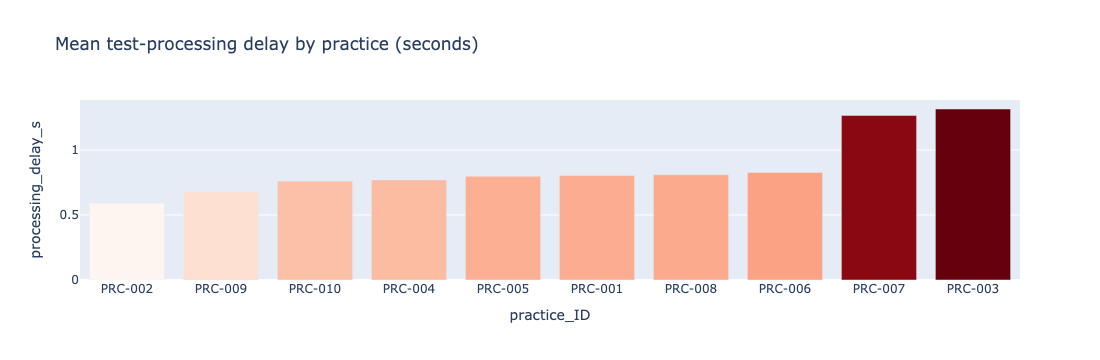

In [11]:
delay = sw.groupby('practice_ID')['processing_delay_s'].mean().reset_index().sort_values('processing_delay_s')
fig = px.bar(delay, x='practice_ID', y='processing_delay_s',
             title='Mean test-processing delay by practice (seconds)',
             color='processing_delay_s', color_continuous_scale='Reds')
fig.update_layout(height=360, coloraxis_showscale=False)
fig.show()

## Finding 4 — Targeted retraining for four administrators

**What we found.** Four administrators have timeout rates 4–9× their same-practice peers — same handsets, same patient population, very different completion rates:

| Admin | Practice | Timeout rate | Tests | Peer rate (same practice) |
|---|---|---|---|---|
| ADM-004 | PRC-002 | **28%** | 268 | 3% |
| ADM-015 | PRC-007 | **24%** | 269 | 4% |
| ADM-011 | PRC-005 | **12%** | 433 | 1% |
| ADM-007 | PRC-003 | **12%** | 294 | 4% |

**Likely cause.** Test-administration technique (patient coaching, mouthpiece fit, cue timing) — not a device fault.

**Action.** Refresher training delivered by the clinical training team for these four named administrators.

In [12]:
admin = sw.groupby(['practice_ID','administrator_ID']).agg(
    tests=('test_log_time','count'),
    timeout_rate=('user_error', lambda s: (s=='Timeout').mean()),
).reset_index()
fleet_median = admin['timeout_rate'].median()

def peer_max(grp):
    rates = grp['timeout_rate'].tolist()
    out = []
    for i, r in enumerate(rates):
        others = [x for j, x in enumerate(rates) if j != i] or [0]
        out.append(max(others))
    grp = grp.copy()
    grp['peer_max'] = out
    return grp

admin = admin.groupby('practice_ID', group_keys=False).apply(peer_max)
admin['flagged'] = ((admin['timeout_rate'] >= 3*fleet_median)
                    & (admin['timeout_rate'] >= 2*admin['peer_max'])
                    & (admin['tests'] >= 50))
admin.sort_values('timeout_rate', ascending=False).head(10).round(3)

/var/folders/f8/xv7djb_n22xgdscpcvdwbcg40000gn/T/ipykernel_73649/1633987605.py:17: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,practice_ID,administrator_ID,tests,timeout_rate,peer_max,flagged
3,PRC-002,ADM-004,268,0.276,0.025,True
14,PRC-007,ADM-015,269,0.242,0.037,True
10,PRC-005,ADM-011,433,0.120,0.012,True
6,PRC-003,ADM-007,294,0.116,0.037,True
22,PRC-010,ADM-023,263,0.053,0.042,False
23,PRC-010,ADM-024,283,0.042,0.053,False
19,PRC-008,ADM-020,307,0.039,0.032,False
15,PRC-007,ADM-016,268,0.037,0.242,False
7,PRC-003,ADM-008,269,0.037,0.116,False
17,PRC-008,ADM-018,249,0.032,0.039,False


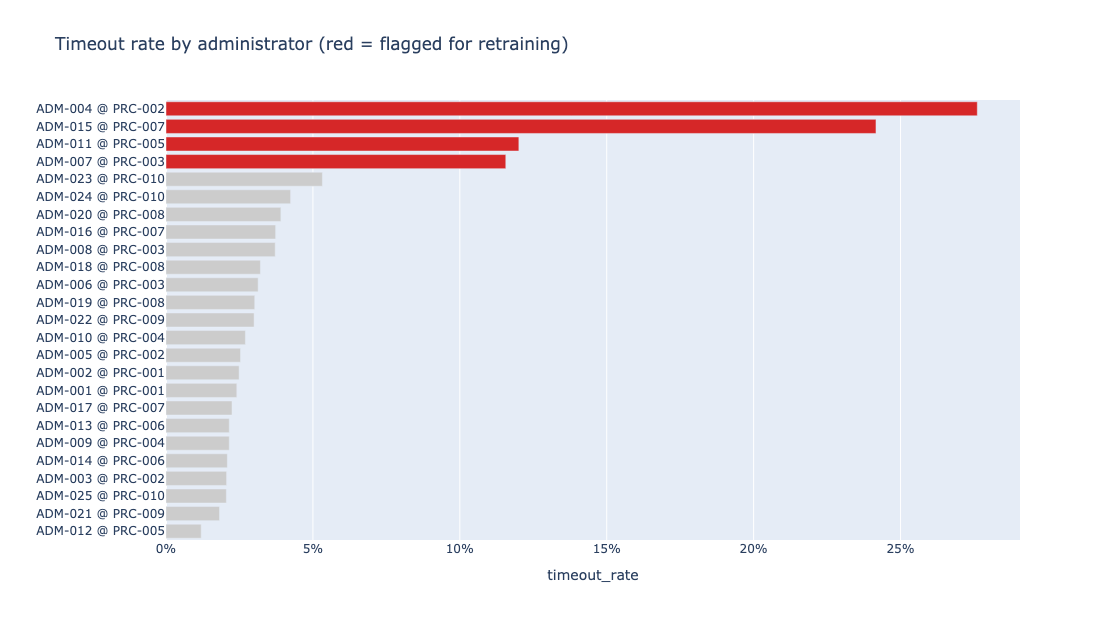

In [13]:
admin['label'] = admin['administrator_ID'] + ' @ ' + admin['practice_ID']
admin_sorted = admin.sort_values('timeout_rate')
fig = px.bar(admin_sorted, x='timeout_rate', y='label', orientation='h',
             color='flagged',
             color_discrete_map={True:'#d62728', False:'#cccccc'},
             title='Timeout rate by administrator (red = flagged for retraining)')
fig.update_layout(height=620, yaxis_title='', xaxis_tickformat='.0%',
                  showlegend=False)
fig.show()

## Finding 5 — Three handsets have a broken telemetry uplink

**What we found.** Three devices stopped sending hardware telemetry mid-study but kept successfully running tests:

In [14]:
dropouts = hh[hh['silence_days'] >= 7][[
    'practice','tests','last_test','last_telemetry','silence_days',
    'telemetry_events','firmware_events','last_firmware'
]].sort_values('silence_days', ascending=False)
dropouts

,practice,tests,last_test,last_telemetry,silence_days,telemetry_events,firmware_events,last_firmware
handset_num,,,,,,,,
3,PRC-002,443,2026-05-06 17:38:07,2026-04-09 08:11:06,27,31,2,1.0.0
12,PRC-006,414,2026-05-06 17:43:18,2026-04-28 08:15:49,8,58,8,2.0.1


**Likely cause.** The telemetry/OTA uplink path is broken on these specific devices, while the test-submission path is healthy. Because firmware updates only take effect at next boot, devices that fail OTA stay on the old version.

**Action.** Field engineer visit to the affected practices: forced power-cycle, console diagnostic, verify OTA delivery audit log. Add a per-device 'last telemetry seen' alarm to the operations dashboard.

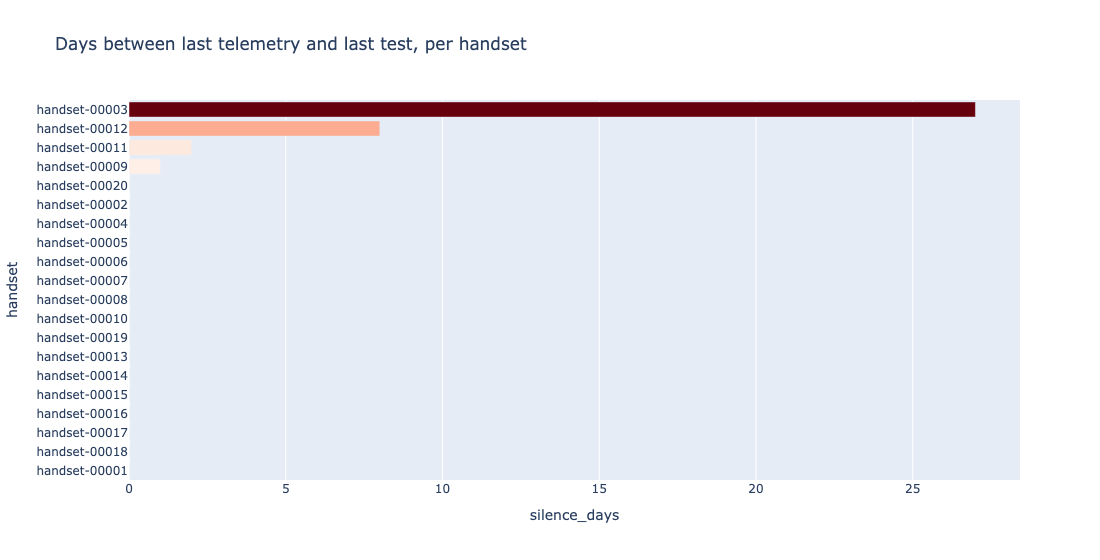

In [15]:
# Visualise telemetry liveness
tel_view = hh[['practice','last_test','last_telemetry','silence_days']].reset_index()
tel_view['handset'] = 'handset-' + tel_view['handset_num'].astype(str).str.zfill(5)
fig = px.bar(tel_view.sort_values('silence_days'), x='silence_days', y='handset',
             orientation='h', color='silence_days',
             color_continuous_scale='Reds',
             title='Days between last telemetry and last test, per handset')
fig.update_layout(height=560, coloraxis_showscale=False)
fig.show()

## Finding 6 — Three handsets stuck on older firmware

**What we found.** While the rest of the fleet has moved to v2.0.1, three handsets are still running older versions:

In [16]:
latest = hh['last_firmware'].mode().iloc[0]
behind = hh[hh['last_firmware'] != latest][[
    'practice','tests','miscal_rate','last_firmware','firmware_events'
]].copy()
print(f'Fleet latest version: {latest}')
behind

Fleet latest version: 2.0.1


,practice,tests,miscal_rate,last_firmware,firmware_events
handset_num,,,,,
3,PRC-002,443,0.020316,1.0.0,2
13,PRC-007,418,0.571770,1.2.0,21
14,PRC-007,386,0.015544,1.2.0,21


**Likely cause.** Same root cause as Finding 5 — the OTA channel never delivered the update, or the device never rebooted to apply it. (The brief states updates take effect at next boot, normally start of day.)

**Action.** Combine with the Finding-5 field visit. Add fleet-wide firmware version as a tracked operations metric — anything >1 release behind triggers an alert.

## Finding 7 — Weekend testing falls outside support coverage

**What we found.** **280 tests (~3.2%)** were run on Saturdays/Sundays, when TidalSense provides no technical support. If a handset fault occurs during weekend testing, the affected patient cannot be re-tested until Monday.

**Likely cause.** Catch-up clinics or staff unaware of the support window.

**Action.** Communicate the support window in onboarding. Optional product improvement: a soft on-screen reminder when a test starts outside supported hours.

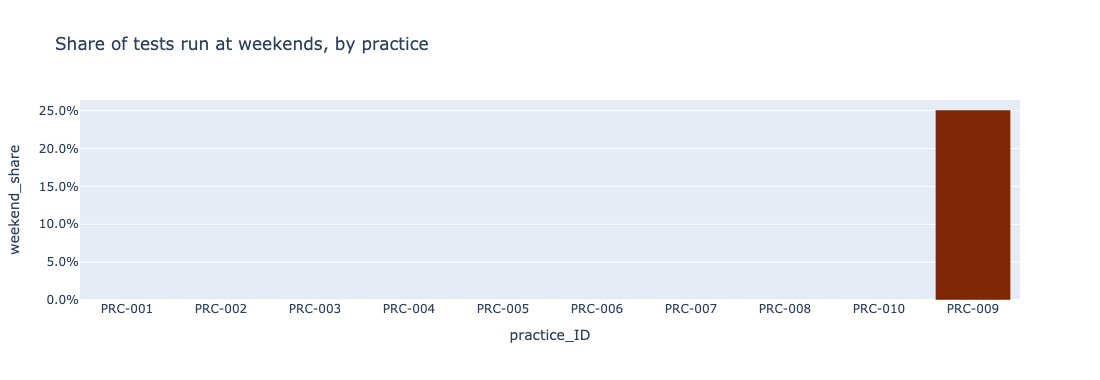

In [17]:
weekend = sw.groupby(['practice_ID','is_weekend']).size().unstack(fill_value=0)
weekend.columns = ['weekday','weekend']
weekend['weekend_share'] = weekend['weekend'] / (weekend['weekday']+weekend['weekend'])
weekend = weekend.reset_index()
fig = px.bar(weekend.sort_values('weekend_share'),
             x='practice_ID', y='weekend_share',
             title='Share of tests run at weekends, by practice',
             color='weekend_share', color_continuous_scale='Oranges')
fig.update_layout(height=380, yaxis_tickformat='.1%', coloraxis_showscale=False)
fig.show()

## Finding 8 — Diagnostic positivity varies 5× between practices

**What we found.** Positive-diagnosis rate ranges from **10%** at PRC-001/PRC-003 to **52%** at PRC-008. This is far wider than we would expect from random patient mix.

**Likely cause.** Most likely a difference in patient referral or inclusion criteria across practices. Less likely but possible: site-level calibration drift biasing results in one direction.

**Action.** Clinical review of referral patterns at the high-positivity sites. To rule out device drift, swap a handset between a high- and a low-positivity site for one week and compare.

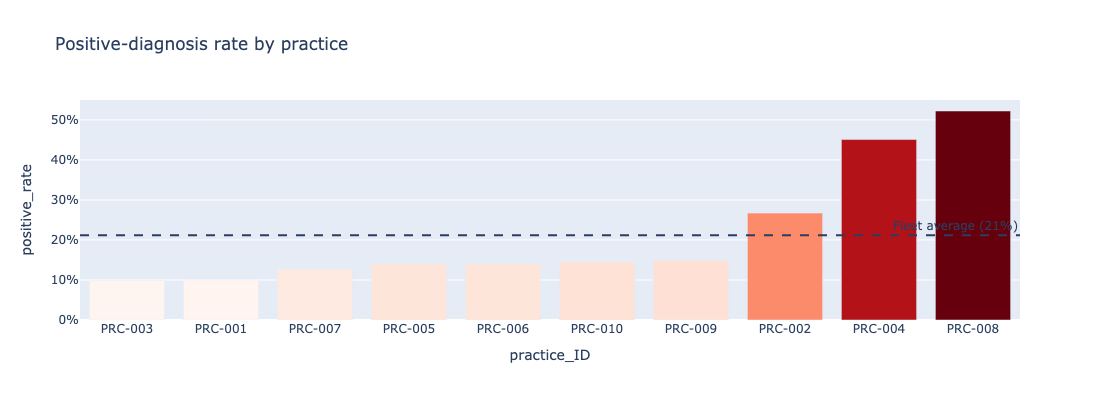

In [18]:
pos = sw.groupby('practice_ID').agg(
    tests=('test_log_time','count'),
    positive_rate=('diagnosis', lambda s: (s=='positive').mean()),
).reset_index().sort_values('positive_rate')
overall = sw['diagnosis'].eq('positive').mean()
fig = px.bar(pos, x='practice_ID', y='positive_rate',
             title='Positive-diagnosis rate by practice',
             color='positive_rate', color_continuous_scale='Reds')
fig.add_hline(y=overall, line_dash='dash',
              annotation_text=f'Fleet average ({overall:.0%})')
fig.update_layout(height=400, yaxis_tickformat='.0%', coloraxis_showscale=False)
fig.show()

## Finding 9 — PRC-009 ran 33% more tests than the median practice

**What we found.** PRC-009 logged **1,116 tests** in the 30-day window vs a per-practice median of **850**. Both their handsets are in the top three by test-volume.

**Likely cause.** Either genuine extra clinical demand (more patients, more clinic capacity), or a workflow artefact such as duplicate logging or repeated test attempts. The data shows no duplicate `test_log_time` rows, which makes duplicate logging less likely but doesn't rule out repeated attempts.

**Action.** Confirm with the practice manager whether the extra volume is expected. If not, audit the workflow for accidental re-tests.

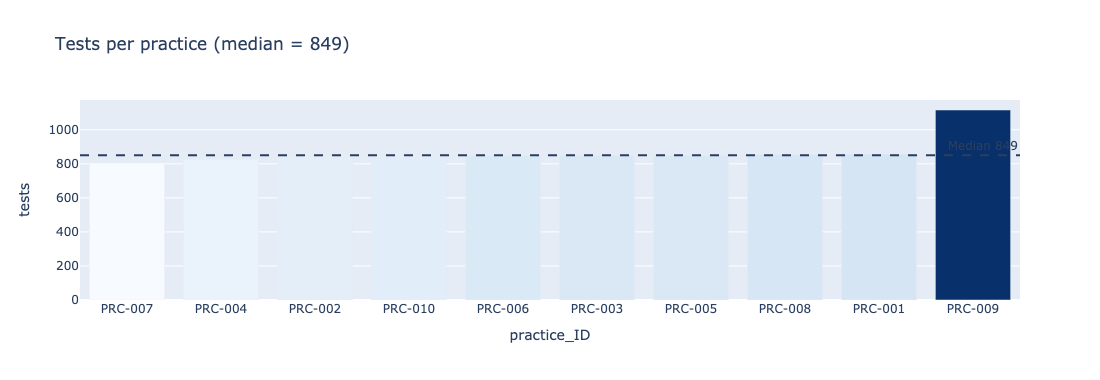

In [19]:
vol = sw.groupby('practice_ID').size().reset_index(name='tests').sort_values('tests')
median = vol['tests'].median()
fig = px.bar(vol, x='practice_ID', y='tests',
             title=f'Tests per practice (median = {int(median)})',
             color='tests', color_continuous_scale='Blues')
fig.add_hline(y=median, line_dash='dash', annotation_text=f'Median {int(median)}')
fig.update_layout(height=380, coloraxis_showscale=False)
fig.show()

---
# Recommendation summary

| # | Action | Priority | Owner | Time-to-impact |
|---|---|---|---|---|
| 1 | Replace handset-00013 at PRC-007 | **P0** | Field ops | 1–2 days |
| 2 | Post-mortem on firmware v1.1.2; add release-gate metric | **P1** | Software | 1 week |
| 3 | Site connectivity survey at PRC-003 and PRC-007 | **P1** | Field ops | 1–2 weeks |
| 4 | Refresher training for four flagged administrators | **P1** | Clinical training | 1 week |
| 5 | Diagnose telemetry/OTA on handsets 3, 12, 13, 14 | **P1** | Field ops + Software | 1–2 weeks |
| 6 | Add fleet firmware version to ops dashboard with stale-version alarm | **P2** | Software | 2 weeks |
| 7 | Clinical review of positivity-rate variance; pilot handset-swap | **P2** | Clinical lead | 2–4 weeks |
| 8 | Confirm PRC-009 extra volume is real demand vs workflow issue | **P2** | Clinical lead | 1 week |
| 9 | Communicate support window; consider in-app weekend reminder | **P3** | Product | 2–4 weeks |

*P0 = act now · P1 = act this week · P2 = act this month · P3 = next planning cycle*